# Домашнее задание

В этом домашнем задании предлагаем вам попрактиковаться в прогнозировании стоимости биткоина при помощи линейной регрессии.

In [76]:
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv("https://raw.githubusercontent.com/aiedu-courses/stepik_applied_tasks/main/datasets/BTC_5min_sample.csv",
                   parse_dates=True,
                   index_col='timestamp'
                  )
data.sort_index(inplace=True)
data.head()

,open,high,low,close,volume
timestamp,,,,,
2023-06-18 00:00:00,26519.10,26542.5,26501.76,26515.80,35.4498
2023-06-18 00:05:00,26508.01,26535.0,26506.13,26511.30,7.4262
2023-06-18 00:10:00,26511.30,26551.0,26508.77,26519.62,18.9461
2023-06-18 00:15:00,26519.44,26550.0,26464.43,26511.99,89.2364
2023-06-18 00:20:00,26513.33,26541.0,26414.28,26439.52,90.0204


<Axes: xlabel='timestamp'>

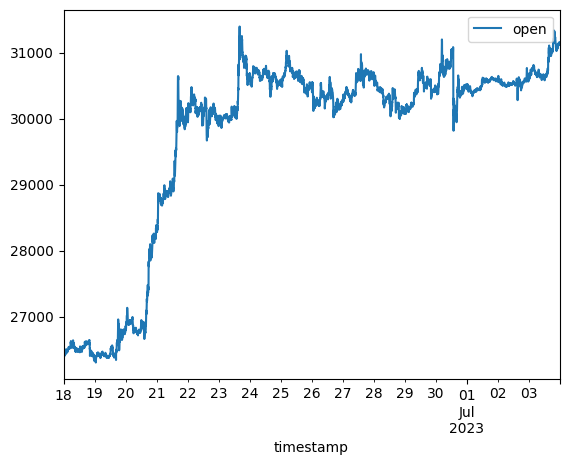

In [77]:
data_subset = data[['open']]

data_subset.plot()

Проделайте следующие шаги:

* Разбейте данные на тренировочную и тестовую часть. В тест отправьте 15% данных

* Извлеките лаговые признаки

* Извлеките агрегированные признаки (средняя стоимость за день, час)

Рекомендуется использовать функцию preprocess_data с вебинара (однако, надо будет незначительно ее поменять, исходя из данных задачи).

Задайте гиперпараметры по умолчанию (в функции preprocess_data, если будете использовать ее):
* `lag_start`=5
* `lag_end`=20
* `test_size`=0.15


### Решение
Зададим параметры, которые будем использовать для прогнозов и по которым будем считать смещения.



In [78]:
LAG_PARAMS = ['open', 'high', 'low', 'close', 'volume']

In [79]:
print(f'Total size of df: {len(data)}')
print(f"Types: {data.dtypes}")

Total size of df: 4608
Types: open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object


In [80]:
def code_mean(df: pd.DataFrame, cat_feature, real_feature):
    return dict(df.groupby(cat_feature)[real_feature].mean())

In [81]:
def preprocess_data(df: pd.DataFrame, lag_start: int=5, lag_end: int=20, test_size: float=0.15):
    train_size = int(len(df) * (1 - test_size))
    df_copy = pd.DataFrame(df.copy())

    # добавляем лаги по параметрам lag_start и lag_end для всех параметров,
    # которые мы решили добавить в LAG_PARAMS
    for param in LAG_PARAMS:
        for i in range(lag_start, lag_end+1):
            df_copy[f"{param}_lag_{i}"] = df_copy[param].shift(i)

    df_copy.dropna(inplace=True)

    # добавим
    # df_copy['month'] = df_copy.index.month
    df_copy['day'] = df_copy.index.day
    df_copy['hour'] = df_copy.index.hour
    df_copy['week'] = df_copy.index.isocalendar().week

    # df_copy['month_average'] = list(map(code_mean(df_copy.iloc[:train_size], "month", "open").get, df_copy.month))
    df_copy['day_average'] = list(map(code_mean(df_copy.iloc[:train_size], "day", "open").get, df_copy.day))
    df_copy['hour_average'] = list(map(code_mean(df_copy.iloc[:train_size], "hour", "open").get, df_copy.hour))
    df_copy['week_average'] = list(map(code_mean(df_copy.iloc[:train_size], "week", "open").get, df_copy.week))

    df_copy.dropna(inplace=True)

    X_train = df_copy.iloc[:train_size].drop(["open"], axis=1)
    y_train = df_copy.iloc[:train_size]["open"]
    X_test = df_copy.iloc[train_size:].drop(["open"], axis=1)
    y_test = df_copy.iloc[train_size:]["open"]

    return X_train, X_test, y_train, y_test

Обучите линейную регрессию с гиперпараметрами по умолчанию на тренировочных данных и вычислите ошибку MAE на тестовых данных.

Чему она получилась равна? (Ответ округлите до целого числа).

Также нарисуйте график правильного ответа и прогноза на тесте.

In [82]:
# Подготовим данные
X_train, X_test, y_train, y_test = preprocess_data(data)

Text(0.5, 1.0, 'Linear Regression\n Mean absolute error: 5.45')

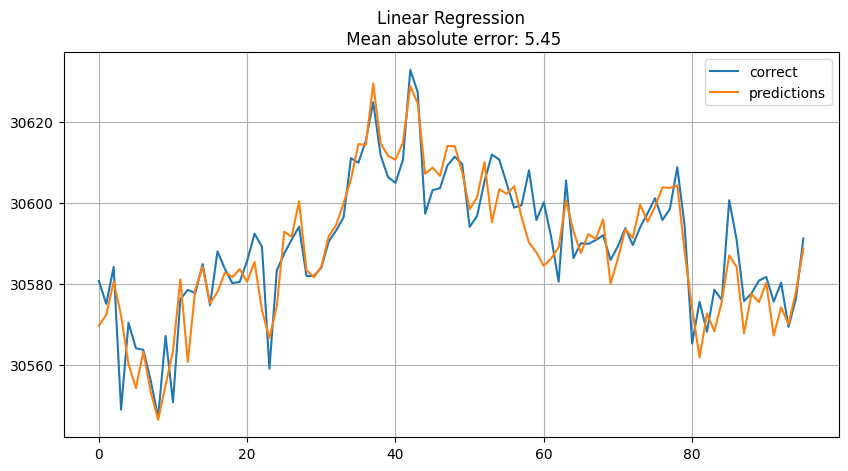

In [83]:
from sklearn.metrics import mean_absolute_error
# Тренировка
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

predictions = lr.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="correct")
plt.plot(predictions, label="predictions")
plt.grid(True)
plt.legend(loc='best')
plt.title(f'Linear Regression\n Mean absolute error: {mean_absolute_error(predictions, y_test):.2f}')


Попробуйте подобрать гиперпараметры `lag_start`, `lag_end`, а также придумать новые полезные агрегрированные признаки для улучшения качества прогноза.

Пропорции разбиения (в тесте 15% данных) не трогайте. Ошибку MAE все так же считайте на тесте.

In [84]:
# your code here